# HCSumm* / Proposed Dual-Feature Call Graph Summarization

Notebook ini menjalankan pipeline dari **file `.py`** sebagai input:

1. Baca dua file Python: `t0` dan `t1`
2. Ekstrak directed call graph
3. Visualisasi call graph dengan Graphviz
4. Ekstrak execution path
5. Hitung fitur perilaku `f(v)`
6. Bangun directed node2vec random walk dengan outgoing edge
7. Latih Word2Vec untuk mendapatkan embedding `e(v)`
8. Normalisasi `f(v)` dan `e(v)`
9. Fusion menjadi `x(v) = [e'(v) || f'(v)]`
10. Hitung Euclidean distance
11. Ward clustering
12. Bangun summary graph

Catatan: random walk node2vec di notebook ini dibuat sendiri agar **arah edge tetap dipertahankan**.

In [1]:
# Kalau dijalankan di environment baru, aktifkan cell ini.
# Di Google Colab / Jupyter, hapus tanda komentar jika package belum tersedia.

!pip install networkx numpy scipy scikit-learn pandas graphviz pydot gensim

In [2]:
!{sys.executable} -m pip install scipy

zsh:1: parse error near `-m'


In [1]:
import ast
import os
import random
import numpy as np
import pandas as pd
import networkx as nx

from IPython.display import display, Image
from graphviz import Digraph

# from sklearn.preprocessing import normalize
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

try:
    from gensim.models import Word2Vec
except Exception as e:
    print("Gensim belum tersedia atau bermasalah. Jalankan: pip install gensim")
    raise e

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Library loaded.")

Library loaded.


## 1. Set path file program t0 dan t1

Ganti `FILE_T0` dan `FILE_T1` sesuai lokasi file `.py` yang ingin dibandingkan.

In [2]:
# =========================
# GANTI PATH FILE DI SINI
# =========================

FILE_T0 = '/Users/fitra/Downloads/anaconda_projects/kode disertasi/coba hcsumm/example/tc6_t0_med.py'
FILE_T1 = '/Users/fitra/Downloads/anaconda_projects/kode disertasi/coba hcsumm/example/tc6_t1_med.py'

# Jumlah cluster untuk dry run / synthetic scenario
K_CLUSTERS = 2

# Parameter directed node2vec
EMBED_DIM = 4
WALK_LENGTH = 10
NUM_WALKS = 200
P_RETURN = 1.0
Q_INOUT = 1.0

print("FILE_T0:", FILE_T0)
print("FILE_T1:", FILE_T1)

FILE_T0: /Users/fitra/Downloads/anaconda_projects/kode disertasi/coba hcsumm/example/tc6_t0_med.py
FILE_T1: /Users/fitra/Downloads/anaconda_projects/kode disertasi/coba hcsumm/example/tc6_t1_med.py


## 2. Fungsi ekstraksi directed call graph dari file `.py`

Extractor ini membaca AST Python dan membangun `nx.DiGraph`.
Node = fungsi/method, edge = relasi pemanggilan fungsi.

Untuk menjaga graf tetap bersih, edge hanya ditambahkan jika callee merupakan fungsi yang didefinisikan di file yang sama.

In [3]:
class CallGraphExtractor(ast.NodeVisitor):
    def __init__(self):
        self.graph = nx.DiGraph()
        self.current_function = None
        self.defined_functions = set()

    def visit_FunctionDef(self, node):
        self.defined_functions.add(node.name)
        self.graph.add_node(node.name)
        self.generic_visit(node)

    def visit_AsyncFunctionDef(self, node):
        self.defined_functions.add(node.name)
        self.graph.add_node(node.name)
        self.generic_visit(node)

def _get_callee_name(call_node):
    if isinstance(call_node.func, ast.Name):
        return call_node.func.id
    if isinstance(call_node.func, ast.Attribute):
        return call_node.func.attr
    return None

class CallEdgeExtractor(ast.NodeVisitor):
    def __init__(self, graph, defined_functions):
        self.graph = graph
        self.defined_functions = defined_functions
        self.current_function = None

    def visit_FunctionDef(self, node):
        prev = self.current_function
        self.current_function = node.name
        self.generic_visit(node)
        self.current_function = prev

    def visit_AsyncFunctionDef(self, node):
        prev = self.current_function
        self.current_function = node.name
        self.generic_visit(node)
        self.current_function = prev

    def visit_Call(self, node):
        callee = _get_callee_name(node)
        if self.current_function and callee in self.defined_functions:
            self.graph.add_edge(self.current_function, callee)
        self.generic_visit(node)

def extract_call_graph_from_py(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        source = f.read()

    tree = ast.parse(source)

    node_extractor = CallGraphExtractor()
    node_extractor.visit(tree)

    edge_extractor = CallEdgeExtractor(node_extractor.graph, node_extractor.defined_functions)
    edge_extractor.visit(tree)

    return node_extractor.graph, source

print("Call graph extractor ready.")

Call graph extractor ready.


## 3. Fungsi visualisasi call graph dengan Graphviz

In [4]:
def graph_to_graphviz(G, title="Call Graph"):
    dot = Digraph(comment=title)
    dot.attr(rankdir="LR")
    dot.attr("node", shape="circle", style="filled", fillcolor="lightblue", fontname="Arial")

    for n in G.nodes():
        dot.node(str(n), str(n))

    for u, v in G.edges():
        dot.edge(str(u), str(v))

    return dot

def show_graph(G, filename, title="Call Graph"):
    dot = graph_to_graphviz(G, title)
    out_path = dot.render(filename, format="png", cleanup=True)
    display(Image(filename=out_path))
    return out_path

print("Graphviz helpers ready.")

Graphviz helpers ready.


## 4. Baca file t0 dan t1, ekstrak call graph, dan visualisasikan

In [5]:
G_t0, source_t0 = extract_call_graph_from_py(FILE_T0)
G_t1, source_t1 = extract_call_graph_from_py(FILE_T1)

print("=== SOURCE t0 ===")
print(source_t0)
print("\n=== SOURCE t1 ===")
print(source_t1)

print("\n=== CALL GRAPH t0 ===")
print("Nodes:", list(G_t0.nodes()))
print("Edges:", list(G_t0.edges()))

print("\n=== CALL GRAPH t1 ===")
print("Nodes:", list(G_t1.nodes()))
print("Edges:", list(G_t1.edges()))

=== SOURCE t0 ===
def A():
    B()
    D()

def B():
    C()

def C():
    H()

def H():
    pass

def D():
    E()
    F()

def E():
    pass

def F():
    G()

def G():
    I()

def I():
    pass

=== SOURCE t1 ===
def A():
    B()
    D()

def B():
    C()

def C():
    H()

def H():
    pass

def D():
    E()
    F()
    J()   # branch baru

def E():
    pass

def F():
    G()

def G():
    I()

def I():
    pass

def J():
    K()

def K():
    L()

def L():
    pass

=== CALL GRAPH t0 ===
Nodes: ['A', 'B', 'C', 'H', 'D', 'E', 'F', 'G', 'I']
Edges: [('A', 'B'), ('A', 'D'), ('B', 'C'), ('C', 'H'), ('D', 'E'), ('D', 'F'), ('F', 'G'), ('G', 'I')]

=== CALL GRAPH t1 ===
Nodes: ['A', 'B', 'C', 'H', 'D', 'E', 'F', 'G', 'I', 'J', 'K', 'L']
Edges: [('A', 'B'), ('A', 'D'), ('B', 'C'), ('C', 'H'), ('D', 'E'), ('D', 'F'), ('D', 'J'), ('F', 'G'), ('G', 'I'), ('J', 'K'), ('K', 'L')]


Visualisasi Call Graph t0


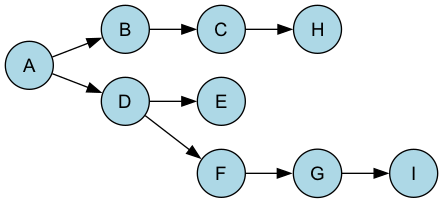

Visualisasi Call Graph t1


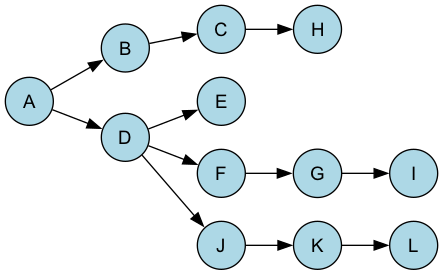

'call_graph_t1.png'

In [6]:
print("Visualisasi Call Graph t0")
show_graph(G_t0, "call_graph_t0", "Call Graph t0")

print("Visualisasi Call Graph t1")
show_graph(G_t1, "call_graph_t1", "Call Graph t1")

# Fungsi-fungsi pipeline HCSumm* / Proposed Method

## 5. Execution path dan fitur perilaku `f(v)`

Definisi yang digunakan:
- Execution path = simple path yang mengikuti arah edge dan berakhir di exit node.
- Exit node = node dengan out-degree 0.
- Node dihitung jika dilewati path, baik sebagai node awal, tengah, maupun akhir.
- `f(v,l)` = jumlah path panjang `l` yang memuat node `v`.

In [8]:
def get_exit_nodes(G):
    return [n for n in G.nodes() if G.out_degree(n) == 0]

def extract_execution_paths(G):
    exit_nodes = get_exit_nodes(G)
    paths = []

    for start in G.nodes():
        for end in exit_nodes:
            if start == end:
                continue
            try:
                for path in nx.all_simple_paths(G, start, end):
                    if len(path) > 1:
                        paths.append(path)
            except nx.NetworkXNoPath:
                pass

    # Remove duplicates while preserving order
    seen = set()
    unique_paths = []
    for p in paths:
        key = tuple(p)
        if key not in seen:
            seen.add(key)
            unique_paths.append(p)

    return unique_paths

def build_path_length_profile(G, paths):
    if not paths:
        return {n: np.array([], dtype=float) for n in G.nodes()}, 0

    L = max(len(p) - 1 for p in paths)
    f = {n: np.zeros(L, dtype=float) for n in G.nodes()}

    for p in paths:
        length = len(p) - 1
        idx = length - 1
        for v in p:
            f[v][idx] += 1

    return f, L

def build_compact_behavior_feature_epl(G, paths):
    # 1. Hitung path-length count profile lama
    f_path, L = build_path_length_profile(G, paths)

    # 2. Hitung EPL dan EPL'
    epl = {}
    epl_norm = {}

    for v, vec in f_path.items():
        total_count = vec.sum()

        if total_count > 0 and L > 0:
            lengths = np.arange(1, L + 1)
            epl[v] = np.sum(lengths * vec) / total_count
            epl_norm[v] = epl[v] / L
        else:
            epl[v] = 0.0
            epl_norm[v] = 0.0

    # 3. Degree feature
    indeg = dict(G.in_degree())
    outdeg = dict(G.out_degree())

    max_indeg = max(indeg.values()) if max(indeg.values()) > 0 else 1
    max_outdeg = max(outdeg.values()) if max(outdeg.values()) > 0 else 1

    # 4. Bentuk f_star compact:
    # f*(v) = [EPL'(v), indeg'(v), outdeg'(v)]
    f_star = {}

    for v in G.nodes():
        indeg_norm = indeg[v] / max_indeg
        outdeg_norm = outdeg[v] / max_outdeg

        f_star[v] = np.array([
            epl_norm[v],
            indeg_norm,
            outdeg_norm
        ])

    return f_star, f_path, epl, epl_norm, indeg, outdeg, L

def normalize_f_l1(f):
    f_norm = {}
    for v, vec in f.items():
        s = vec.sum()
        if s > 0:
            f_norm[v] = vec / s
        else:
            f_norm[v] = vec.copy()
    return f_norm

def print_paths(paths):
    for i, p in enumerate(paths, 1):
        print(f"P{i}: {' -> '.join(map(str, p))} | length={len(p)-1}")

def features_to_dataframe(feat_dict, prefix="dim"):
    if not feat_dict:
        return pd.DataFrame()
    nodes = list(feat_dict.keys())
    max_len = max((len(v) for v in feat_dict.values()), default=0)
    data = []
    for n in nodes:
        vec = feat_dict[n]
        row = list(vec) + [np.nan] * (max_len - len(vec))
        data.append(row)
    cols = [f"{prefix}{i+1}" for i in range(max_len)]
    return pd.DataFrame(data, index=nodes, columns=cols)

def compute_node_depth(G):
    # root = semua node dengan indeg = 0
    roots = [n for n, d in G.in_degree() if d == 0]

    # inisialisasi depth
    depth = {v: float('inf') for v in G.nodes()}

    # BFS dari semua root
    from collections import deque

    queue = deque()
    for r in roots:
        depth[r] = 0
        queue.append(r)

    while queue:
        u = queue.popleft()
        for v in G.successors(u):
            if depth[v] > depth[u] + 1:
                depth[v] = depth[u] + 1
                queue.append(v)

    return depth
    
def build_compact_behavior_feature_epl(G, paths):
    import numpy as np

    # 1. Path-length profile
    f_path, L = build_path_length_profile(G, paths)

    # 2. EPL
    epl = {}
    epl_norm = {}

    for v, vec in f_path.items():
        total = vec.sum()
        if total > 0 and L > 0:
            lengths = np.arange(1, L + 1)
            epl[v] = np.sum(lengths * vec) / total
            epl_norm[v] = epl[v] / L
        else:
            epl[v] = 0.0
            epl_norm[v] = 0.0

    # 3. Degree
    indeg = dict(G.in_degree())
    outdeg = dict(G.out_degree())

    max_indeg = max(indeg.values()) if max(indeg.values()) > 0 else 1
    max_outdeg = max(outdeg.values()) if max(outdeg.values()) > 0 else 1

    # 4. Depth
    depth = compute_node_depth(G)
    max_depth = max([d for d in depth.values() if d < float('inf')]) if depth else 1

    depth_norm = {}
    for v in G.nodes():
        if depth[v] == float('inf'):
            depth_norm[v] = 1.0
        else:
            depth_norm[v] = depth[v] / max_depth if max_depth > 0 else 0.0

    # 5. Final f*(v)
    f_star = {}

    for v in G.nodes():
        indeg_norm = indeg[v] / max_indeg
        outdeg_norm = outdeg[v] / max_outdeg

        f_star[v] = np.array([
            epl_norm[v],
            indeg_norm,
            outdeg_norm,
            depth_norm[v]
        ])

    return f_star, f_path, epl, epl_norm, indeg, outdeg, depth, depth_norm, L

print("Execution path and f(v) functions ready.")

Execution path and f(v) functions ready.


## 6. Directed node2vec random walk

Bagian ini memastikan random walk hanya mengikuti **outgoing neighbors**.
Dengan demikian, sequence walk tetap mempertahankan arah pada call graph.

In [9]:
def directed_node2vec_walk(G, start_node, walk_length, p=1.0, q=1.0):
    walk = [start_node]

    while len(walk) < walk_length:
        curr = walk[-1]
        neighbors = list(G.successors(curr))  # penting: outgoing neighbors saja

        if len(neighbors) == 0:
            break  # exit node

        if len(walk) == 1:
            next_node = random.choice(neighbors)
        else:
            prev = walk[-2]
            weights = []

            for nbr in neighbors:
                if nbr == prev:
                    weight = 1.0 / p
                elif G.has_edge(prev, nbr) or G.has_edge(nbr, prev):
                    weight = 1.0
                else:
                    weight = 1.0 / q
                weights.append(weight)

            probs = np.array(weights, dtype=float)
            probs = probs / probs.sum()
            next_node = np.random.choice(neighbors, p=probs)

        walk.append(next_node)

    return walk

def generate_directed_node2vec_walks(G, num_walks=80, walk_length=10, p=1.0, q=1.0, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    nodes = list(G.nodes())
    walks = []

    for _ in range(num_walks):
        random.shuffle(nodes)
        for n in nodes:
            walk = directed_node2vec_walk(G, n, walk_length, p=p, q=q)
            walks.append([str(x) for x in walk])

    return walks

def compute_directed_node2vec_embedding(
    G,
    dimensions=4,
    walk_length=10,
    num_walks=200,
    p=1.0,
    q=1.0,
    seed=42,
    window=5,
    epochs=100
):
    walks = generate_directed_node2vec_walks(
        G,
        num_walks=num_walks,
        walk_length=walk_length,
        p=p,
        q=q,
        seed=seed
    )

    model = Word2Vec(
        sentences=walks,
        vector_size=dimensions,
        window=window,
        min_count=1,
        sg=1,          # skip-gram
        workers=1,
        seed=seed,
        epochs=epochs
    )

    e = {}
    for n in G.nodes():
        key = str(n)
        if key in model.wv:
            e[n] = model.wv[key]
        else:
            # fallback jika node tidak muncul dalam walk
            e[n] = np.zeros(dimensions)

    return e, walks, model

def normalize_e_l2(e):
    e_norm = {}
    for v, vec in e.items():
        norm = np.linalg.norm(vec)
        if norm > 0:
            e_norm[v] = vec / norm
        else:
            e_norm[v] = vec.copy()
    return e_norm

print("Directed node2vec functions ready.")

Directed node2vec functions ready.


## 7. Fusion, distance, Ward clustering, dan summary graph

In [10]:
def align_feature_dimensions(feat_dict, target_len):
    aligned = {}
    for n, vec in feat_dict.items():
        vec = np.asarray(vec, dtype=float)
        if len(vec) < target_len:
            vec = np.concatenate([vec, np.zeros(target_len - len(vec))])
        aligned[n] = vec
    return aligned

def fuse_features(e_norm, f_norm, alpha=1.0, beta=1.0):
    nodes = list(e_norm.keys())
    x = {}
    for n in nodes:
        x[n] = np.concatenate([alpha * e_norm[n], beta * f_norm[n]])
    return x

def compute_distance_matrix(x):
    nodes = list(x.keys())
    X = np.array([x[n] for n in nodes])

    if len(nodes) <= 1:
        return nodes, np.zeros((len(nodes), len(nodes)))

    dist = squareform(pdist(X, metric="euclidean"))
    return nodes, dist

def ward_clustering(x, k=2):
    nodes = list(x.keys())
    X = np.array([x[n] for n in nodes])

    if len(nodes) == 0:
        return {}, None
    if len(nodes) == 1:
        return {1: [nodes[0]]}, None

    k = min(k, len(nodes))
    Z = linkage(X, method="ward")
    labels = fcluster(Z, k, criterion="maxclust")

    clusters = {}
    for i, n in enumerate(nodes):
        clusters.setdefault(int(labels[i]), []).append(n)

    return clusters, Z

def build_summary_graph(G, clusters):
    node_to_cluster = {}
    for cid, members in clusters.items():
        for n in members:
            node_to_cluster[n] = cid

    S = nx.DiGraph()
    for cid in clusters:
        S.add_node(f"C{cid}")

    for u, v in G.edges():
        cu = node_to_cluster.get(u)
        cv = node_to_cluster.get(v)
        if cu is not None and cv is not None and cu != cv:
            S.add_edge(f"C{cu}", f"C{cv}")

    return S, node_to_cluster

def print_clusters(clusters):
    for cid, members in sorted(clusters.items()):
        print(f"C{cid}: {members}")

print("Fusion, distance, clustering, and summary graph functions ready.")

Fusion, distance, clustering, and summary graph functions ready.


# Proses t0 satu per satu

## 8. t0 — Execution path

In [11]:
paths_t0 = extract_execution_paths(G_t0)
exit_t0 = get_exit_nodes(G_t0)

print("Exit nodes t0:", exit_t0)
print("\nExecution paths t0:")
print_paths(paths_t0)

Exit nodes t0: ['H', 'E', 'I']

Execution paths t0:
P1: A -> B -> C -> H | length=3
P2: A -> D -> E | length=2
P3: A -> D -> F -> G -> I | length=4
P4: B -> C -> H | length=2
P5: C -> H | length=1
P6: D -> E | length=1
P7: D -> F -> G -> I | length=3
P8: F -> G -> I | length=2
P9: G -> I | length=1


## 9. t0 — Hitung `f(v)` dan normalisasi `f'(v)`

In [12]:
#f_t0, L_t0 = build_path_length_profile(G_t0, paths_t0)
#f_norm_t0 = normalize_f_l1(f_t0)
#f_star_t0, f_t0, f_norm_t0, indeg_t0, outdeg_t0, L_t0 = build_enriched_behavior_feature(G_t0, paths_t0)
f_star_t0, f_t0, epl_t0, epl_norm_t0, indeg_t0, outdeg_t0, depth_t0, depth_norm_t0, L_t0 = build_compact_behavior_feature_epl(G_t0, paths_t0)

print("L_t0 =", L_t0)

print("\nRaw f_path(v) t0:")
display(features_to_dataframe(f_t0, prefix="f"))

print("\nEPL(v) t0:")
display(pd.DataFrame.from_dict(epl_t0, orient="index", columns=["EPL"]))

print("\nEPL'(v) t0:")
display(pd.DataFrame.from_dict(epl_norm_t0, orient="index", columns=["EPL'"]))

print("\nIn-degree t0:")
display(pd.DataFrame.from_dict(indeg_t0, orient="index", columns=["indeg"]))

print("\nOut-degree t0:")
display(pd.DataFrame.from_dict(outdeg_t0, orient="index", columns=["outdeg"]))

print("\nDepth t0:")
display(pd.DataFrame.from_dict(depth_t0, orient="index", columns=["depth"]))

print("\nNormalized depth t0:")
display(pd.DataFrame.from_dict(depth_norm_t0, orient="index", columns=["depth'"]))

print("\nUpdated f*(v) t0:")
display(features_to_dataframe(f_star_t0, prefix="f*"))

#print("\nCompact behavior feature f*(v) t0:")
#display(features_to_dataframe(f_star_t0, prefix="f*"))

L_t0 = 4

Raw f_path(v) t0:


,f1,f2,f3,f4
A,0.0,1.0,1.0,1.0
B,0.0,1.0,1.0,0.0
C,1.0,1.0,1.0,0.0
H,1.0,1.0,1.0,0.0
D,1.0,1.0,1.0,1.0
E,1.0,1.0,0.0,0.0
F,0.0,1.0,1.0,1.0
G,1.0,1.0,1.0,1.0
I,1.0,1.0,1.0,1.0



EPL(v) t0:


,EPL
A,3.0
B,2.5
C,2.0
H,2.0
D,2.5
E,1.5
F,3.0
G,2.5
I,2.5



EPL'(v) t0:


...

,depth
A,0
B,1
C,2
H,3
D,1
E,2
F,2
G,3
I,4



Normalized depth t0:


,depth'
A,0.00
B,0.25
C,0.50
H,0.75
D,0.25
E,0.50
F,0.50
G,0.75
I,1.00



Updated f*(v) t0:


,f*1,f*2,f*3,f*4
A,0.750,0.0,1.0,0.00
B,0.625,1.0,0.5,0.25
C,0.500,1.0,0.5,0.50
H,0.500,1.0,0.0,0.75
D,0.625,1.0,1.0,0.25
E,0.375,1.0,0.0,0.50
F,0.750,1.0,0.5,0.50
G,0.625,1.0,0.5,0.75
I,0.625,1.0,0.0,1.00


## 10. t0 — Directed node2vec random walk dan embedding `e(v)`

In [13]:
e_t0, walks_t0, model_t0 = compute_directed_node2vec_embedding(
    G_t0,
    dimensions=EMBED_DIM,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P_RETURN,
    q=Q_INOUT,
    seed=SEED
)

print("Contoh 10 random walks t0:")
for w in walks_t0[:10]:
    print(" -> ".join(w))

print("\nRaw e(v) t0:")
display(features_to_dataframe(e_t0, prefix="e"))

Contoh 10 random walks t0:
H
F -> G -> I
G -> I
D -> E
I
C -> H
E
A -> B -> C -> H
B -> C -> H
G -> I

Raw e(v) t0:


,e1,e2,e3,e4
A,-0.833202,0.506598,0.388358,0.353874
B,-0.970477,1.918979,-0.093926,0.530591
C,0.052638,2.192408,1.069703,1.506187
H,-1.068091,2.146965,-1.082422,0.892497
D,-0.047450,-0.228631,0.011688,1.637580
E,-1.475979,-0.044210,0.900252,1.016498
F,-1.355005,-0.749717,-0.714314,1.425595
G,-0.609143,-1.025002,0.265122,2.389264
I,-1.982283,-0.637125,0.191099,0.976038


## 11. t0 — Normalisasi `e(v)` menjadi `e'(v)`

In [14]:
e_norm_t0 = normalize_e_l2(e_t0)

print("Normalized e'(v) t0:")
display(features_to_dataframe(e_norm_t0, prefix="e'"))

Normalized e'(v) t0:


,e'1,e'2,e'3,e'4
A,-0.752216,0.457358,0.350610,0.319478
B,-0.437763,0.865613,-0.042368,0.239339
C,0.018357,0.764584,0.373050,0.525270
H,-0.384452,0.772786,-0.389611,0.321249
D,-0.028685,-0.138214,0.007066,0.989962
E,-0.735768,-0.022039,0.448771,0.506719
F,-0.609604,-0.337290,-0.321363,0.641361
G,-0.227005,-0.381981,0.098801,0.890392
I,-0.859062,-0.276111,0.082817,0.422985


## 12. t0 — Fusion menjadi `x(v)`

In [15]:
# Pastikan dimensi f(v) konsisten dengan L lokal t0
#f_norm_t0_aligned = align_feature_dimensions(f_norm_t0, L_t0)

#x_t0 = fuse_features(e_norm_t0, f_norm_t0_aligned, alpha=1.0, beta=1.0)
x_t0 = fuse_features(e_norm_t0, f_star_t0, alpha=1.0, beta=1.0)

print("Fused representation x(v) t0:")
display(features_to_dataframe(x_t0, prefix="x"))

Fused representation x(v) t0:


,x1,x2,x3,x4,x5,x6,x7,x8
A,-0.752216,0.457358,0.350610,0.319478,0.750,0.0,1.0,0.00
B,-0.437763,0.865613,-0.042368,0.239339,0.625,1.0,0.5,0.25
C,0.018357,0.764584,0.373050,0.525270,0.500,1.0,0.5,0.50
H,-0.384452,0.772786,-0.389611,0.321249,0.500,1.0,0.0,0.75
D,-0.028685,-0.138214,0.007066,0.989962,0.625,1.0,1.0,0.25
E,-0.735768,-0.022039,0.448771,0.506719,0.375,1.0,0.0,0.50
F,-0.609604,-0.337290,-0.321363,0.641361,0.750,1.0,0.5,0.50
G,-0.227005,-0.381981,0.098801,0.890392,0.625,1.0,0.5,0.75
I,-0.859062,-0.276111,0.082817,0.422985,0.625,1.0,0.0,1.00


## 13. t0 — Euclidean distance berdasarkan `x(v)`

In [16]:
nodes_t0, dist_t0 = compute_distance_matrix(x_t0)

dist_df_t0 = pd.DataFrame(dist_t0, index=nodes_t0, columns=nodes_t0)
print("Distance matrix t0:")
display(dist_df_t0.round(4))

Distance matrix t0:


,A,B,C,H,D,E,F,G,I
A,0.0000,1.3246,1.5144,1.8460,1.5887,1.6326,1.6453,1.7882,1.9098
B,1.3246,0.0000,0.7421,0.8089,1.4110,1.2508,1.3394,1.5148,1.5307
C,1.5144,0.7421,0.0000,1.0479,1.2228,1.2080,1.4720,1.2890,1.5695
H,1.8460,0.8089,1.0479,0.0000,1.6813,1.2532,1.3286,1.4786,1.2795
D,1.5887,1.4110,1.2228,1.6813,0.0000,1.4377,0.9668,0.7855,1.6119
E,1.6326,1.2508,1.2080,1.2532,1.4377,0.0000,1.0570,1.0164,0.7302
F,1.6453,1.3394,1.4720,1.3286,0.9668,1.0570,0.0000,0.6820,0.8903
G,1.7882,1.5148,1.2890,1.4786,0.7855,1.0164,0.6820,0.0000,0.9705
I,1.9098,1.5307,1.5695,1.2795,1.6119,0.7302,0.8903,0.9705,0.0000


## 14. t0 — Ward clustering

In [17]:
clusters_t0, Z_t0 = ward_clustering(x_t0, k=K_CLUSTERS)

print("Clusters t0:")
print_clusters(clusters_t0)

if Z_t0 is not None:
    print("\nWard linkage matrix t0:")
    display(pd.DataFrame(Z_t0, columns=["cluster_1", "cluster_2", "distance", "size"]))

def explain_ward_merges(Z, nodes):
    cluster_map = {i: [nodes[i]] for i in range(len(nodes))}

    print("\nUrutan merge Ward clustering:")
    for step, row in enumerate(Z, start=1):
        c1, c2, dist, size = row
        c1 = int(c1)
        c2 = int(c2)

        members_1 = cluster_map[c1]
        members_2 = cluster_map[c2]

        new_cluster = members_1 + members_2
        new_id = len(nodes) + step - 1
        cluster_map[new_id] = new_cluster

        print(f"Iterasi {step}: merge {members_1} + {members_2} -> {new_cluster}")
        print(f"  linkage distance = {dist:.4f}, size = {int(size)}")

if Z_t0 is not None:
    explain_ward_merges(Z_t0, list(x_t0.keys()))

Clusters t0:
C1: ['D', 'E', 'F', 'G', 'I']
C2: ['A', 'B', 'C', 'H']

Ward linkage matrix t0:


,cluster_1,cluster_2,distance,size
0,6.0,7.0,0.681952,2.0
1,5.0,8.0,0.730197,2.0
2,1.0,2.0,0.742096,2.0
3,4.0,9.0,0.937786,3.0
4,3.0,11.0,0.992343,3.0
5,10.0,12.0,1.600733,5.0
6,0.0,13.0,1.828662,4.0
7,14.0,15.0,2.254943,9.0



Urutan merge Ward clustering:
Iterasi 1: merge ['F'] + ['G'] -> ['F', 'G']
  linkage distance = 0.6820, size = 2
Iterasi 2: merge ['E'] + ['I'] -> ['E', 'I']
  linkage distance = 0.7302, size = 2
Iterasi 3: merge ['B'] + ['C'] -> ['B', 'C']
  linkage distance = 0.7421, size = 2
Iterasi 4: merge ['D'] + ['F', 'G'] -> ['D', 'F', 'G']
  linkage distance = 0.9378, size = 3
Iterasi 5: merge ['H'] + ['B', 'C'] -> ['H', 'B', 'C']
  linkage distance = 0.9923, size = 3
Iterasi 6: merge ['E', 'I'] + ['D', 'F', 'G'] -> ['E', 'I', 'D', 'F', 'G']
  linkage distance = 1.6007, size = 5
Iterasi 7: merge ['A'] + ['H', 'B', 'C'] -> ['A', 'H', 'B', 'C']
  linkage distance = 1.8287, size = 4
Iterasi 8: merge ['E', 'I', 'D', 'F', 'G'] + ['A', 'H', 'B', 'C'] -> ['E', 'I', 'D', 'F', 'G', 'A', 'H', 'B', 'C']
  linkage distance = 2.2549, size = 9


## 15. t0 — Summary graph

Node to cluster mapping t0:
{'A': 2, 'B': 2, 'C': 2, 'H': 2, 'D': 1, 'E': 1, 'F': 1, 'G': 1, 'I': 1}

Summary graph edges t0:
[('C2', 'C1')]

Visualisasi Summary Graph t0


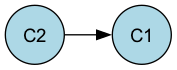

'summary_graph_t0.png'

In [18]:
S_t0, node_to_cluster_t0 = build_summary_graph(G_t0, clusters_t0)

print("Node to cluster mapping t0:")
print(node_to_cluster_t0)

print("\nSummary graph edges t0:")
print(list(S_t0.edges()))

print("\nVisualisasi Summary Graph t0")
show_graph(S_t0, "summary_graph_t0", "Summary Graph t0")

# Proses t1 satu per satu

## 16. t1 — Execution path

In [19]:
paths_t1 = extract_execution_paths(G_t1)
exit_t1 = get_exit_nodes(G_t1)

print("Exit nodes t1:", exit_t1)
print("\nExecution paths t1:")
print_paths(paths_t1)

Exit nodes t1: ['H', 'E', 'I', 'L']

Execution paths t1:
P1: A -> B -> C -> H | length=3
P2: A -> D -> E | length=2
P3: A -> D -> F -> G -> I | length=4
P4: A -> D -> J -> K -> L | length=4
P5: B -> C -> H | length=2
P6: C -> H | length=1
P7: D -> E | length=1
P8: D -> F -> G -> I | length=3
P9: D -> J -> K -> L | length=3
P10: F -> G -> I | length=2
P11: G -> I | length=1
P12: J -> K -> L | length=2
P13: K -> L | length=1


## 17. t1 — Hitung `f(v)` dan normalisasi `f'(v)`

In [20]:
#f_t1, L_t1 = build_path_length_profile(G_t1, paths_t1)
#f_norm_t1 = normalize_f_l1(f_t1)

f_star_t1, f_t1, epl_t1, epl_norm_t1, indeg_t1, outdeg_t1, depth_t1, depth_norm_t1, L_t1 = build_compact_behavior_feature_epl(G_t1, paths_t1)

print("L_t1 =", L_t1)

print("\nRaw f_path(v) t1:")
display(features_to_dataframe(f_t1, prefix="f"))

print("\nEPL(v) t1:")
display(pd.DataFrame.from_dict(epl_t1, orient="index", columns=["EPL"]))

print("\nEPL'(v) t1:")
display(pd.DataFrame.from_dict(epl_norm_t1, orient="index", columns=["EPL'"]))

print("\nIn-degree t1:")
display(pd.DataFrame.from_dict(indeg_t1, orient="index", columns=["indeg"]))

print("\nOut-degree t1:")
display(pd.DataFrame.from_dict(outdeg_t1, orient="index", columns=["outdeg"]))

print("\nDepth t1:")
display(pd.DataFrame.from_dict(depth_t1, orient="index", columns=["depth"]))

print("\nNormalized depth t1:")
display(pd.DataFrame.from_dict(depth_norm_t1, orient="index", columns=["depth'"]))

print("\nUpdated f*(v) t1:")
display(features_to_dataframe(f_star_t1, prefix="f*"))

L_t1 = 4

Raw f_path(v) t1:


,f1,f2,f3,f4
A,0.0,1.0,1.0,2.0
B,0.0,1.0,1.0,0.0
C,1.0,1.0,1.0,0.0
H,1.0,1.0,1.0,0.0
D,1.0,1.0,2.0,2.0
E,1.0,1.0,0.0,0.0
F,0.0,1.0,1.0,1.0
G,1.0,1.0,1.0,1.0
I,1.0,1.0,1.0,1.0
J,0.0,1.0,1.0,1.0



EPL(v) t1:


,EPL
A,3.250000
B,2.500000
C,2.000000
H,2.000000
D,2.833333
E,1.500000
F,3.000000
G,2.500000
I,2.500000
J,3.000000



EPL'(v) t1:


...

,depth
A,0
B,1
C,2
H,3
D,1
E,2
F,2
G,3
I,4
J,2



Normalized depth t1:


,depth'
A,0.00
B,0.25
C,0.50
H,0.75
D,0.25
E,0.50
F,0.50
G,0.75
I,1.00
J,0.50



Updated f*(v) t1:


,f*1,f*2,f*3,f*4
A,0.812500,0.0,0.666667,0.00
B,0.625000,1.0,0.333333,0.25
C,0.500000,1.0,0.333333,0.50
H,0.500000,1.0,0.000000,0.75
D,0.708333,1.0,1.000000,0.25
E,0.375000,1.0,0.000000,0.50
F,0.750000,1.0,0.333333,0.50
G,0.625000,1.0,0.333333,0.75
I,0.625000,1.0,0.000000,1.00
J,0.750000,1.0,0.333333,0.50


## 18. t1 — Directed node2vec random walk dan embedding `e(v)`

In [21]:
e_t1, walks_t1, model_t1 = compute_directed_node2vec_embedding(
    G_t1,
    dimensions=EMBED_DIM,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P_RETURN,
    q=Q_INOUT,
    seed=SEED
)

print("Contoh 10 random walks t1:")
for w in walks_t1[:10]:
    print(" -> ".join(w))

print("\nRaw e(v) t1:")
display(features_to_dataframe(e_t1, prefix="e"))

Contoh 10 random walks t1:
G -> I
E
C -> H
I
J -> K -> L
F -> G -> I
L
H
D -> E
A -> B -> C -> H

Raw e(v) t1:


,e1,e2,e3,e4
A,-0.617954,0.789840,-0.067887,0.169825
B,-1.843150,1.608150,-0.504851,-0.305878
C,-2.603693,1.441716,0.382099,-0.873169
H,-1.680807,2.349279,-1.376460,0.375880
D,-0.453237,0.224094,1.072319,0.669515
E,-0.475142,0.995338,0.074719,1.444485
F,-1.551649,-0.461020,0.561962,1.517745
G,-1.708489,-0.082882,-0.743729,2.712333
I,-2.226511,-0.615898,1.451931,1.616056
J,0.344897,2.245090,0.705209,1.099957


## 19. t1 — Normalisasi `e(v)` menjadi `e'(v)`

In [22]:
e_norm_t1 = normalize_e_l2(e_t1)

print("Normalized e'(v) t1:")
display(features_to_dataframe(e_norm_t1, prefix="e'"))

Normalized e'(v) t1:


,e'1,e'2,e'3,e'4
A,-0.606198,0.774813,-0.066595,0.166595
B,-0.732483,0.639092,-0.200632,-0.121558
C,-0.833158,0.461336,0.122268,-0.279406
H,-0.521694,0.729177,-0.427230,0.116667
D,-0.332888,0.164590,0.787585,0.491738
E,-0.261218,0.547205,0.041078,0.794132
F,-0.677873,-0.201407,0.245506,0.663061
G,-0.519020,-0.025179,-0.225937,0.823976
I,-0.702107,-0.194217,0.457851,0.509606
J,0.131619,0.856767,0.269120,0.419763


## 20. t1 — Fusion menjadi `x(v)`

In [24]:
x_t1 = fuse_features(e_norm_t1, f_star_t1, alpha=1.0, beta=1.0)

print("Fused representation x(v) t1:")
display(features_to_dataframe(x_t1, prefix="x"))

Fused representation x(v) t1:


,x1,x2,x3,x4,x5,x6,x7,x8
A,-0.606198,0.774813,-0.066595,0.166595,0.812500,0.0,0.666667,0.00
B,-0.732483,0.639092,-0.200632,-0.121558,0.625000,1.0,0.333333,0.25
C,-0.833158,0.461336,0.122268,-0.279406,0.500000,1.0,0.333333,0.50
H,-0.521694,0.729177,-0.427230,0.116667,0.500000,1.0,0.000000,0.75
D,-0.332888,0.164590,0.787585,0.491738,0.708333,1.0,1.000000,0.25
E,-0.261218,0.547205,0.041078,0.794132,0.375000,1.0,0.000000,0.50
F,-0.677873,-0.201407,0.245506,0.663061,0.750000,1.0,0.333333,0.50
G,-0.519020,-0.025179,-0.225937,0.823976,0.625000,1.0,0.333333,0.75
I,-0.702107,-0.194217,0.457851,0.509606,0.625000,1.0,0.000000,1.00
J,0.131619,0.856767,0.269120,0.419763,0.750000,1.0,0.333333,0.50


## 21. t1 — Euclidean distance berdasarkan `x(v)`

In [25]:
nodes_t1, dist_t1 = compute_distance_matrix(x_t1)

dist_df_t1 = pd.DataFrame(dist_t1, index=nodes_t1, columns=nodes_t1)
print("Distance matrix t1:")
display(dist_df_t1.round(4))

Distance matrix t1:


,A,B,C,H,D,E,F,G,I,J,K,L
A,0.0000,1.1594,1.3576,1.4988,1.5706,1.5691,1.6331,1.6775,1.9546,1.4467,1.6882,1.8244
B,1.1594,0.0000,0.4990,0.7331,1.4795,1.1677,1.2658,1.2773,1.4835,1.1772,1.4459,1.3966
C,1.3576,0.4990,0.0000,0.8951,1.3878,1.2729,1.1955,1.3237,1.2485,1.2884,1.4339,1.2082
H,1.4988,0.7331,0.8951,0.0000,1.8067,0.9259,1.3703,1.1120,1.3788,1.1207,1.3034,1.2387
D,1.5706,1.4795,1.3878,1.8067,0.0000,1.4049,1.0416,1.3819,1.3941,1.2155,1.0984,1.4178
E,1.5691,1.1677,1.2729,0.9259,1.4049,0.0000,1.0221,0.8381,1.1451,0.8331,0.7635,1.1045
F,1.6331,1.2658,1.1955,1.3703,1.0416,1.0221,0.0000,0.6185,0.6678,1.3545,1.1611,1.3978
G,1.6775,1.2773,1.3237,1.1120,1.3819,0.8381,0.6185,0.0000,0.8956,1.2991,1.1194,1.4731
I,1.9546,1.4835,1.2485,1.3788,1.3941,1.1451,0.6678,0.8956,0.0000,1.4900,1.2057,1.1423
J,1.4467,1.1772,1.2884,1.1207,1.2155,0.8331,1.3545,1.2991,1.4900,0.0000,0.5271,0.8597


## 22. t1 — Ward clustering

In [26]:
clusters_t1, Z_t1 = ward_clustering(x_t1, k=K_CLUSTERS)

print("Clusters t1:")
print_clusters(clusters_t1)

if Z_t1 is not None:
    print("\nWard linkage matrix t1:")
    display(pd.DataFrame(Z_t1, columns=["cluster_1", "cluster_2", "distance", "size"]))

if Z_t1 is not None:
    explain_ward_merges(Z_t1, list(x_t1.keys()))

Clusters t1:
C1: ['A', 'B', 'C', 'H']
C2: ['D', 'E', 'F', 'G', 'I', 'J', 'K', 'L']

Ward linkage matrix t1:


,cluster_1,cluster_2,distance,size
0,1.0,2.0,0.499037,2.0
1,9.0,10.0,0.527121,2.0
2,6.0,7.0,0.618520,2.0
3,8.0,14.0,0.839377,3.0
4,5.0,13.0,0.871020,3.0
5,3.0,12.0,0.899646,3.0
6,11.0,16.0,1.010288,4.0
7,4.0,15.0,1.482312,4.0
8,0.0,17.0,1.565957,4.0
9,18.0,19.0,1.888735,8.0



Urutan merge Ward clustering:
Iterasi 1: merge ['B'] + ['C'] -> ['B', 'C']
  linkage distance = 0.4990, size = 2
Iterasi 2: merge ['J'] + ['K'] -> ['J', 'K']
  linkage distance = 0.5271, size = 2
Iterasi 3: merge ['F'] + ['G'] -> ['F', 'G']
  linkage distance = 0.6185, size = 2
Iterasi 4: merge ['I'] + ['F', 'G'] -> ['I', 'F', 'G']
  linkage distance = 0.8394, size = 3
Iterasi 5: merge ['E'] + ['J', 'K'] -> ['E', 'J', 'K']
  linkage distance = 0.8710, size = 3
Iterasi 6: merge ['H'] + ['B', 'C'] -> ['H', 'B', 'C']
  linkage distance = 0.8996, size = 3
Iterasi 7: merge ['L'] + ['E', 'J', 'K'] -> ['L', 'E', 'J', 'K']
  linkage distance = 1.0103, size = 4
Iterasi 8: merge ['D'] + ['I', 'F', 'G'] -> ['D', 'I', 'F', 'G']
  linkage distance = 1.4823, size = 4
Iterasi 9: merge ['A'] + ['H', 'B', 'C'] -> ['A', 'H', 'B', 'C']
  linkage distance = 1.5660, size = 4
Iterasi 10: merge ['L', 'E', 'J', 'K'] + ['D', 'I', 'F', 'G'] -> ['L', 'E', 'J', 'K', 'D', 'I', 'F', 'G']
  linkage distance = 1.888

## 23. t1 — Summary graph

Node to cluster mapping t1:
{'A': 1, 'B': 1, 'C': 1, 'H': 1, 'D': 2, 'E': 2, 'F': 2, 'G': 2, 'I': 2, 'J': 2, 'K': 2, 'L': 2}

Summary graph edges t1:
[('C1', 'C2')]

Visualisasi Summary Graph t1


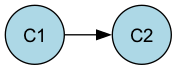

'summary_graph_t1.png'

In [27]:
S_t1, node_to_cluster_t1 = build_summary_graph(G_t1, clusters_t1)

print("Node to cluster mapping t1:")
print(node_to_cluster_t1)

print("\nSummary graph edges t1:")
print(list(S_t1.edges()))

print("\nVisualisasi Summary Graph t1")
show_graph(S_t1, "summary_graph_t1", "Summary Graph t1")

# 24. Rekap hasil t0 vs t1

In [28]:
recap = pd.DataFrame([
    {
        "version": "t0",
        "nodes": G_t0.number_of_nodes(),
        "edges": G_t0.number_of_edges(),
        "exit_nodes": exit_t0,
        "num_paths": len(paths_t0),
        "L": L_t0,
        "clusters": clusters_t0,
        "summary_edges": list(S_t0.edges())
    },
    {
        "version": "t1",
        "nodes": G_t1.number_of_nodes(),
        "edges": G_t1.number_of_edges(),
        "exit_nodes": exit_t1,
        "num_paths": len(paths_t1),
        "L": L_t1,
        "clusters": clusters_t1,
        "summary_edges": list(S_t1.edges())
    }
])

display(recap)

,version,nodes,edges,exit_nodes,num_paths,L,clusters,summary_edges
0,t0,9,8,"[H, E, I]",9,4,"{2: ['A', 'B', 'C', 'H'], 1: ['D', 'E', 'F', '...","[(C2, C1)]"
1,t1,12,11,"[H, E, I, L]",13,4,"{1: ['A', 'B', 'C', 'H'], 2: ['D', 'E', 'F', '...","[(C1, C2)]"


# 25. Optional: Jalankan pipeline sekaligus untuk satu file

Cell ini berguna nanti saat ingin menjalankan banyak test case.

In [37]:
def run_full_pipeline(file_path, k=2, label="graph"):
    G, source = extract_call_graph_from_py(file_path)

    print("="*80)
    print(f"FILE: {file_path}")
    print("="*80)

    print("\n[1] Nodes and edges")
    print("Nodes:", list(G.nodes()))
    print("Edges:", list(G.edges()))

    print("\n[2] Execution paths")
    paths = extract_execution_paths(G)
    print_paths(paths)

    print("\n[3] f(v)")
    f, L = build_path_length_profile(G, paths)
    f_norm = normalize_f_l1(f)
    display(features_to_dataframe(f, prefix="f"))
    print("L =", L)

    print("\n[4] f'(v)")
    display(features_to_dataframe(f_norm, prefix="f'"))

    print("\n[5] directed node2vec walks and e(v)")
    e, walks, model = compute_directed_node2vec_embedding(
        G,
        dimensions=EMBED_DIM,
        walk_length=WALK_LENGTH,
        num_walks=NUM_WALKS,
        p=P_RETURN,
        q=Q_INOUT,
        seed=SEED
    )
    print("Sample walks:")
    for w in walks[:5]:
        print(" -> ".join(w))
    display(features_to_dataframe(e, prefix="e"))

    print("\n[6] e'(v)")
    e_norm = normalize_e_l2(e)
    display(features_to_dataframe(e_norm, prefix="e'"))

    print("\n[7] x(v)")
    f_norm_aligned = align_feature_dimensions(f_norm, L)
    x = fuse_features(e_norm, f_norm_aligned)
    display(features_to_dataframe(x, prefix="x"))

    print("\n[8] Distance matrix")
    nodes, dist = compute_distance_matrix(x)
    display(pd.DataFrame(dist, index=nodes, columns=nodes).round(4))

    print("\n[9] Ward clustering")
    clusters, Z = ward_clustering(x, k=k)
    print_clusters(clusters)

    print("\n[10] Summary graph")
    S, node_to_cluster = build_summary_graph(G, clusters)
    print("Node to cluster:", node_to_cluster)
    print("Summary edges:", list(S.edges()))

    return {
        "G": G,
        "source": source,
        "paths": paths,
        "f": f,
        "f_norm": f_norm,
        "L": L,
        "e": e,
        "e_norm": e_norm,
        "x": x,
        "clusters": clusters,
        "summary_graph": S,
        "node_to_cluster": node_to_cluster
    }

# Contoh pemakaian:
# result_t0 = run_full_pipeline(FILE_T0, k=K_CLUSTERS, label="t0")
# result_t1 = run_full_pipeline(FILE_T1, k=K_CLUSTERS, label="t1")